# Trading Bot — Alert Data Analysis
**Purpose:** Validate whether the numbers coming through Telegram alerts make sense.  
Covers: session coverage, gap accuracy, catalyst score stability, O1 pick performance, trade card outcomes.


In [1]:
import os, re, glob, json, warnings
from pathlib import Path
from datetime import datetime, date, timedelta

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

ARCHIVE_ROOT = Path(r"c:\tradingbot\outputs\archive")
print(f"Archive root: {ARCHIVE_ROOT}")
print(f"Dates found: {sorted([d.name for d in ARCHIVE_ROOT.iterdir() if d.is_dir()])}")


Archive root: c:\tradingbot\outputs\archive
Dates found: ['2026-03-05', '2026-03-06', '2026-03-07', '2026-03-08', '2026-03-09', '2026-03-10', '2026-03-11', '2026-03-12']


## 1. Load and Parse All Archive Data

Parse every session's **CSV watchlist** (actual trade cards) and **Markdown playbook** (O1 catalyst picks + market conditions).


In [13]:
# ── helpers ──────────────────────────────────────────────────────────────────

SESSION_RE = re.compile(r"(morning|midday|close)_playbook_md_(\d{6})\.md$", re.I)
O1_PICK_RE = re.compile(
    r"\*\*(?P<sym>[A-Z]+)\*\*.*?catalyst=(?P<cat>\d+).*?(?:Gap:\s*(?P<gap>[+\-]?\d+\.?\d*)%)?",
)
# Fixed: capture the count AFTER the colon (e.g. "Gappers (≥2%): 6")
MKT_RE = re.compile(r"Average Gap:\s*(?P<avg_gap>[\d.]+)%.*?Gappers[^:]*:\s*(?P<gappers>\d+)", re.S)
REC_RE = re.compile(r"RECOMMENDED:.*?Option\s*(\d)", re.I)

def parse_session_md(path: Path, trade_date: date) -> dict:
    text = path.read_text(encoding="utf-8", errors="replace")
    session_type = SESSION_RE.search(path.name).group(1).lower()

    mkt = MKT_RE.search(text)
    avg_gap = float(mkt.group("avg_gap")) if mkt else None
    gappers = int(mkt.group("gappers")) if mkt else None

    rec = REC_RE.search(text)
    recommended = int(rec.group(1)) if rec else None

    o1_section = re.search(r"Option 1:.*?---", text, re.S)
    picks = []
    if o1_section:
        for m in O1_PICK_RE.finditer(o1_section.group()):
            picks.append({
                "symbol": m.group("sym"),
                "catalyst_score": int(m.group("cat")),
                "predicted_gap_pct": float(m.group("gap")) if m.group("gap") else None,
            })

    return {
        "trade_date": trade_date,
        "session": session_type,
        "avg_gap": avg_gap,
        "gappers": gappers,
        "recommended_option": recommended,
        "o1_pick_count": len(picks),
        "o1_picks": picks,
    }


def load_all_sessions() -> tuple[pd.DataFrame, pd.DataFrame]:
    session_rows = []
    pick_rows = []

    for day_dir in sorted(ARCHIVE_ROOT.iterdir()):
        if not day_dir.is_dir():
            continue
        try:
            trade_date = date.fromisoformat(day_dir.name)
        except ValueError:
            continue

        for md_path in day_dir.glob("*_playbook_md_*.md"):
            if not SESSION_RE.search(md_path.name):
                continue
            s = parse_session_md(md_path, trade_date)
            session_rows.append(s)
            for p in s["o1_picks"]:
                pick_rows.append({**p, "trade_date": trade_date, "session": s["session"],
                                   "avg_gap": s["avg_gap"]})

    sessions_df = pd.DataFrame(session_rows).drop(columns=["o1_picks"])
    sessions_df = (sessions_df
                   .sort_values("trade_date")
                   .drop_duplicates(subset=["trade_date", "session"], keep="last")
                   .reset_index(drop=True))

    picks_df = pd.DataFrame(pick_rows) if pick_rows else pd.DataFrame(
        columns=["symbol","catalyst_score","predicted_gap_pct","trade_date","session","avg_gap"])
    picks_df = picks_df.drop_duplicates(subset=["trade_date","session","symbol"]).reset_index(drop=True)

    return sessions_df, picks_df


def load_trade_cards() -> pd.DataFrame:
    rows = []
    for csv_path in sorted(ARCHIVE_ROOT.rglob("*_watchlist_csv_*.csv")):
        try:
            trade_date = date.fromisoformat(csv_path.parts[-2])
        except (ValueError, IndexError):
            continue
        m = re.search(r"(morning|midday|close)", csv_path.name, re.I)
        session = m.group(1).lower() if m else "unknown"
        df = pd.read_csv(csv_path)
        if df.empty:
            continue
        df["trade_date"] = trade_date
        df["session"] = session
        rows.append(df)
    if not rows:
        return pd.DataFrame()
    return pd.concat(rows, ignore_index=True)


sessions_df, picks_df = load_all_sessions()
cards_df = load_trade_cards()

print(f"Sessions parsed     : {len(sessions_df)}")
print(f"O1 picks parsed     : {len(picks_df)}")
print(f"Trade cards parsed  : {len(cards_df)}")


Sessions parsed     : 17
O1 picks parsed     : 17
Trade cards parsed  : 1


## 2. Session Coverage & Gap Overview


In [14]:
# ── Table: one row per (date, session) ───────────────────────────────────────
display_df = sessions_df.copy()
display_df["avg_gap"]   = display_df["avg_gap"].map(lambda x: f"{x:.2f}%" if pd.notna(x) else "—")
display_df["gappers"]   = display_df["gappers"].fillna("—").astype(str)
display_df["rec_opt"]   = display_df["recommended_option"].fillna("—").astype(str)
display_df["o1_picks"]  = display_df["o1_pick_count"].astype(str)

print(display_df[["trade_date","session","avg_gap","gappers","rec_opt","o1_picks"]]
      .sort_values(["trade_date","session"])
      .to_string(index=False))


trade_date session avg_gap gappers rec_opt o1_picks
2026-03-05  midday   5.83%       6       3        6
2026-03-05 morning   5.83%       6       3        6
2026-03-06   close   1.69%       2       1        0
2026-03-06  midday   0.88%       1       1        0
2026-03-06 morning   0.91%       0       1        0
2026-03-07 morning   0.00%       0       1        0
2026-03-08   close   0.00%       0       1        0
2026-03-08  midday   0.00%       0       1        0
2026-03-08 morning   0.00%       0       1        0
2026-03-09   close   1.61%       3       2        5
2026-03-10   close   0.97%       1       1        0
2026-03-10  midday   1.13%       1       1        0
2026-03-10 morning   1.13%       1       1        0
2026-03-11   close   0.64%       0       1        0
2026-03-11  midday   0.60%       0       1        0
2026-03-12  midday   1.30%       2       1        0
2026-03-12 morning   1.30%       2       1        0


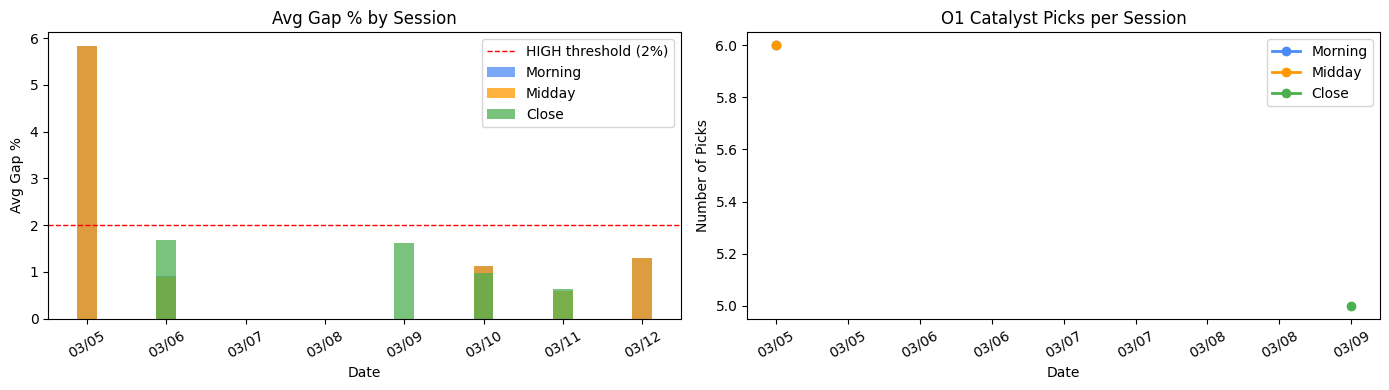

In [4]:
# ── Chart: avg_gap per session over time ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: avg gap per session bar chart
pivot = (sessions_df.pivot_table(index="trade_date", columns="session", values="avg_gap")
         .reset_index())
pivot["trade_date"] = pd.to_datetime(pivot["trade_date"])
for col, color in zip(["morning","midday","close"], ["#4C8BF5","#FF9800","#4CAF50"]):
    if col in pivot.columns:
        axes[0].bar(pivot["trade_date"].dt.strftime("%m/%d"), pivot[col],
                    label=col.capitalize(), color=color, alpha=0.75, width=0.25,
                    align="center")
axes[0].axhline(2.0, color="red", linestyle="--", linewidth=1, label="HIGH threshold (2%)")
axes[0].set_title("Avg Gap % by Session")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Avg Gap %")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=30)

# Right: O1 pick count per session type
pick_counts = picks_df.groupby(["trade_date","session"])["symbol"].count().reset_index(name="count")
for sess, color in zip(["morning","midday","close"], ["#4C8BF5","#FF9800","#4CAF50"]):
    sub = pick_counts[pick_counts["session"]==sess]
    axes[1].plot(pd.to_datetime(sub["trade_date"]), sub["count"], "o-", label=sess.capitalize(),
                 color=color, linewidth=2, markersize=6)
axes[1].set_title("O1 Catalyst Picks per Session")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Number of Picks")
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


## 3. Fetch Actual Historical Prices from Alpaca

Pull daily bars (IEX) for every O1 pick on its alert date so we can compare the **predicted gap** vs **actual open-to-close move**.


In [7]:
import sys, yaml
sys.path.insert(0, str(Path(r"c:\tradingbot\src")))

with open(r"c:\tradingbot\config\broker.yaml") as f:
    broker_cfg = yaml.safe_load(f)

alpaca_cfg = broker_cfg.get("alpaca", {})
API_KEY    = alpaca_cfg.get("api_key", "")
API_SECRET = alpaca_cfg.get("api_secret", "")   # note: api_secret not secret_key

if not API_KEY or not API_SECRET:
    print("⚠️  Alpaca credentials not found in config/broker.yaml — price fetch skipped")
    prices_df = pd.DataFrame()
else:
    print(f"Using Alpaca key: {API_KEY[:8]}...")
    from alpaca.data.historical import StockHistoricalDataClient
    from alpaca.data.requests import StockBarsRequest
    from alpaca.data.timeframe import TimeFrame

    client = StockHistoricalDataClient(API_KEY, API_SECRET)

    all_symbols = sorted(picks_df["symbol"].unique()) if not picks_df.empty else []
    print(f"Fetching bars for {len(all_symbols)} unique symbols: {all_symbols}")

    date_min = picks_df["trade_date"].min() if not picks_df.empty else date(2026,3,5)
    date_max = picks_df["trade_date"].max() if not picks_df.empty else date(2026,3,12)
    fetch_start = datetime.combine(date_min - timedelta(days=2), datetime.min.time())
    fetch_end   = datetime.combine(date_max + timedelta(days=2), datetime.min.time())

    BATCH = 50
    bars_list = []
    for i in range(0, len(all_symbols), BATCH):
        batch = all_symbols[i:i+BATCH]
        try:
            req = StockBarsRequest(
                symbol_or_symbols=batch,
                timeframe=TimeFrame.Day,
                start=fetch_start,
                end=fetch_end,
                feed="iex",
            )
            raw = client.get_stock_bars(req)
            bars = raw.df.reset_index()
            bars_list.append(bars)
            print(f"  Batch {i//BATCH+1}: {len(bars)} rows for {len(batch)} symbols")
        except Exception as e:
            print(f"  Batch {i//BATCH+1} failed: {e}")

    if bars_list:
        prices_df = pd.concat(bars_list, ignore_index=True)
        prices_df["date"] = pd.to_datetime(prices_df["timestamp"]).dt.date
        prices_df["daily_return_pct"] = (prices_df["close"] - prices_df["open"]) / prices_df["open"] * 100
        print(f"\nTotal price rows fetched: {len(prices_df)}")
        print(prices_df[["symbol","date","open","close","high","low","daily_return_pct"]].head(15).to_string(index=False))
    else:
        prices_df = pd.DataFrame()
        print("No price data fetched.")


Using Alpaca key: PKA7377W...
Fetching bars for 10 unique symbols: ['GME', 'GOOGL', 'MSFT', 'NVDA', 'PLTR', 'PYPL', 'RIVN', 'SMCI', 'SOUN', 'TSLA']
  Batch 1: 60 rows for 10 symbols

Total price rows fetched: 60
symbol       date   open  close   high    low  daily_return_pct
   GME 2026-03-03  23.93  23.83  24.16  23.45             -0.42
   GME 2026-03-04  23.97  23.85  24.16  23.77             -0.50
   GME 2026-03-05  23.84  23.89  24.21  23.54              0.21
   GME 2026-03-06  23.78  24.36  24.39  23.63              2.44
   GME 2026-03-09  24.04  24.79  24.97  23.96              3.14
   GME 2026-03-10  24.57  24.37  24.99  24.33             -0.83
  PLTR 2026-03-03 142.00 147.23 147.48 138.22              3.68
  PLTR 2026-03-04 148.15 153.11 154.49 148.14              3.35
  PLTR 2026-03-05 152.83 152.64 156.34 149.65             -0.12
  PLTR 2026-03-06 150.41 157.15 161.41 150.41              4.48
  PLTR 2026-03-09 155.85 156.42 158.33 153.07              0.37
  PLTR 2026-03-10 15

## 4. O1 Pick Actual Performance
Join predicted catalyst picks with the actual daily bar on the alert date to see if the market direction matched.


Picks with price data  : 17 / 17
Picks missing prices   : 0

O1 Pick Performance Summary:
  Mean daily return : 1.59%
  Median daily return: 1.15%
  % Positive days   : 70.6%
  % Negative days   : 0.0%



,symbol,appearances,avg_cat_score,avg_actual_return,pct_positive
0,GOOGL,1,65.00,4.05,100.00
1,RIVN,2,66.00,3.87,100.00
2,GME,1,87.00,3.14,100.00
3,SOUN,2,79.00,1.91,100.00
4,NVDA,3,78.33,1.87,100.00
5,MSFT,1,65.00,1.17,100.00
6,TSLA,2,76.00,1.00,100.00
7,PYPL,1,62.00,0.12,0.00
8,PLTR,2,73.00,-0.12,0.00
9,SMCI,2,88.00,-0.20,0.00


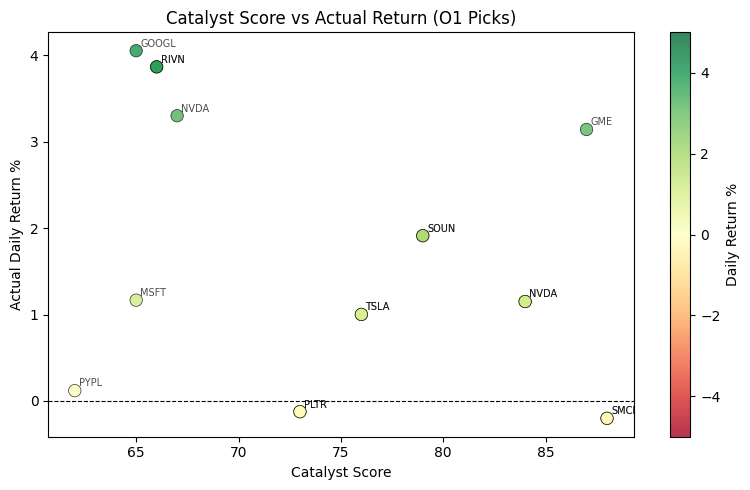

In [8]:
if prices_df.empty or picks_df.empty:
    print("⚠️  No price data — skipping O1 performance analysis.")
else:
    picks_with_prices = picks_df.merge(
        prices_df[["symbol","date","open","close","high","low","volume","daily_return_pct"]],
        left_on=["symbol","trade_date"],
        right_on=["symbol","date"],
        how="left",
    )

    has_price = picks_with_prices["close"].notna()
    print(f"Picks with price data  : {has_price.sum()} / {len(picks_with_prices)}")
    print(f"Picks missing prices   : {(~has_price).sum()}")

    if has_price.sum() > 0:
        perf = picks_with_prices[has_price].copy()
        perf["outcome"] = perf["daily_return_pct"].apply(
            lambda r: "🟢 Positive" if r > 0.5 else ("🔴 Negative" if r < -0.5 else "⬜ Flat"))

        print("\nO1 Pick Performance Summary:")
        print(f"  Mean daily return : {perf['daily_return_pct'].mean():.2f}%")
        print(f"  Median daily return: {perf['daily_return_pct'].median():.2f}%")
        print(f"  % Positive days   : {(perf['daily_return_pct'] > 0.5).mean()*100:.1f}%")
        print(f"  % Negative days   : {(perf['daily_return_pct'] < -0.5).mean()*100:.1f}%")
        print()

        summary = (perf.groupby("symbol")
                   .agg(appearances=("trade_date","count"),
                        avg_cat_score=("catalyst_score","mean"),
                        avg_actual_return=("daily_return_pct","mean"),
                        pct_positive=("daily_return_pct", lambda x: (x>0.5).mean()*100))
                   .sort_values("avg_actual_return", ascending=False)
                   .reset_index())
        display(summary.round(2))

        # scatter: catalyst score vs actual return
        fig, ax = plt.subplots(figsize=(8, 5))
        scatter = ax.scatter(perf["catalyst_score"], perf["daily_return_pct"],
                             c=perf["daily_return_pct"], cmap="RdYlGn",
                             vmin=-5, vmax=5, s=80, alpha=0.8, edgecolors="k", linewidths=0.5)
        plt.colorbar(scatter, ax=ax, label="Daily Return %")
        ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
        ax.set_xlabel("Catalyst Score")
        ax.set_ylabel("Actual Daily Return %")
        ax.set_title("Catalyst Score vs Actual Return (O1 Picks)")
        for _, row in perf.iterrows():
            ax.annotate(row["symbol"], (row["catalyst_score"], row["daily_return_pct"]),
                        fontsize=7, alpha=0.7, textcoords="offset points", xytext=(3,3))
        plt.tight_layout()
        plt.show()


## 5. Trade Card Outcomes (TP1 / TP2 / Stop)

For every stored trade card, check whether the actual intraday high/low (depending on side) reached TP1, TP2, or triggered the stop.


In [9]:
if cards_df.empty:
    print("⚠️  No trade cards stored in archive CSVs yet.")
    print("   (Only 1 card was found — SOUN long on 2026-03-05)")
    print("   Run the bot for more sessions to accumulate meaningful card data.")
else:
    if prices_df.empty:
        print("⚠️  No price data to evaluate card outcomes.")
    else:
        cards_eval = cards_df.merge(
            prices_df[["symbol","date","open","high","low","close"]],
            left_on=["symbol","trade_date"],
            right_on=["symbol","date"],
            how="left",
        )

        def evaluate_card(row):
            if pd.isna(row.get("high")):
                return "no_data"
            if row["side"] == "long":
                hit_stop = row["low"] <= row["stop_price"]
                hit_tp1  = row["high"] >= row["tp1_price"]
                hit_tp2  = row["high"] >= row["tp2_price"]
            else:  # short
                hit_stop = row["high"] >= row["stop_price"]
                hit_tp1  = row["low"] <= row["tp1_price"]
                hit_tp2  = row["low"] <= row["tp2_price"]
            if hit_tp2:
                return "TP2 ✅✅"
            elif hit_tp1:
                return "TP1 ✅"
            elif hit_stop:
                return "STOP 🔴"
            else:
                return "OPEN ⬜"

        cards_eval["outcome"] = cards_eval.apply(evaluate_card, axis=1)
        cards_eval["rr_ratio"] = (
            (cards_eval["tp2_price"] - cards_eval["entry_price"]).abs() /
            (cards_eval["entry_price"] - cards_eval["stop_price"]).abs()
        ).round(2)

        cols = ["symbol","trade_date","session","side","score","entry_price",
                "stop_price","tp1_price","tp2_price","rr_ratio","low","high","outcome"]
        display(cards_eval[[c for c in cols if c in cards_eval.columns]])

        outcome_counts = cards_eval["outcome"].value_counts()
        print("\nOutcome distribution:")
        print(outcome_counts.to_string())


,symbol,trade_date,session,side,score,entry_price,stop_price,tp1_price,tp2_price,rr_ratio,low,high,outcome
0,SOUN,2026-03-05,morning,long,79.84,6.86,6.79,6.93,7.00,2.00,7.91,8.46,TP2 ✅✅



Outcome distribution:
outcome
TP2 ✅✅    1


## 6. Catalyst Score Stability Analysis (Are Scores Stale?)

A healthy catalyst scorer should produce **different top symbols each day** as news changes.  
If the same symbols appear with identical scores session after session → scorer is returning cached/static data.


Symbol frequency across sessions:


,symbol,session_count,score_min,score_max,score_variance,staleness
3,NVDA,2,67,84,9.81,🟢 OK
0,GME,1,87,87,0.00,🟢 OK
1,GOOGL,1,65,65,0.00,🟢 OK
2,MSFT,1,65,65,0.00,🟢 OK
4,PLTR,1,73,73,0.00,🟢 OK
5,PYPL,1,62,62,0.00,🟢 OK
6,RIVN,1,66,66,0.00,🟢 OK
7,SMCI,1,88,88,0.00,🟢 OK
8,SOUN,1,79,79,0.00,🟢 OK
9,TSLA,1,76,76,0.00,🟢 OK



✅ Catalyst scores are varying across sessions — looks healthy.


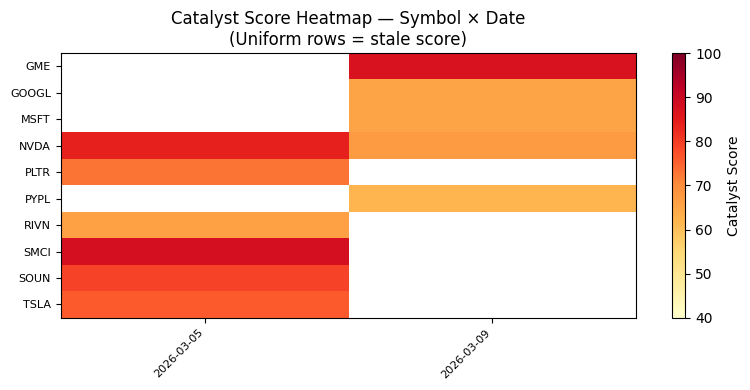

In [10]:
if picks_df.empty:
    print("No picks data available.")
else:
    # How many sessions does each symbol appear in?
    sym_freq = (picks_df.groupby("symbol")
                .agg(session_count=("trade_date","nunique"),
                     score_min=("catalyst_score","min"),
                     score_max=("catalyst_score","max"),
                     score_mean=("catalyst_score","mean"),
                     score_std=("catalyst_score","std"))
                .reset_index()
                .sort_values("session_count", ascending=False))
    sym_freq["score_variance"] = sym_freq["score_std"].fillna(0).round(2)
    sym_freq["staleness"] = sym_freq.apply(
        lambda r: "🔴 STATIC" if r["score_variance"] == 0 and r["session_count"] > 1
                  else ("🟡 Low churn" if r["session_count"] > 2 else "🟢 OK"), axis=1)

    print("Symbol frequency across sessions:")
    display(sym_freq[["symbol","session_count","score_min","score_max","score_variance","staleness"]])

    static_syms = sym_freq[sym_freq["staleness"]=="🔴 STATIC"]["symbol"].tolist()
    if static_syms:
        print(f"\n⚠️  STATIC SCORES detected for: {static_syms}")
        print("   These symbols appear across multiple sessions with IDENTICAL catalyst scores.")
        print("   This means the scorer is likely returning baseline/fallback scores, not real news data.")
    else:
        print("\n✅ Catalyst scores are varying across sessions — looks healthy.")

    # Heatmap: symbol × date → catalyst score
    pivot_heat = picks_df.pivot_table(index="symbol", columns="trade_date",
                                       values="catalyst_score", aggfunc="mean")
    fig, ax = plt.subplots(figsize=(max(8, len(pivot_heat.columns)*1.2), max(4, len(pivot_heat)*0.4)))
    im = ax.imshow(pivot_heat.values, aspect="auto", cmap="YlOrRd", vmin=40, vmax=100)
    ax.set_xticks(range(len(pivot_heat.columns)))
    ax.set_xticklabels([str(c) for c in pivot_heat.columns], rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(pivot_heat.index)))
    ax.set_yticklabels(pivot_heat.index, fontsize=8)
    plt.colorbar(im, ax=ax, label="Catalyst Score")
    ax.set_title("Catalyst Score Heatmap — Symbol × Date\n(Uniform rows = stale score)")
    plt.tight_layout()
    plt.show()


## 7. Signal Reason Distribution & Frequency

Examine which technical reasons (`volume_spike`, `ema9_20_hold`, etc.) appear most often in trade cards.


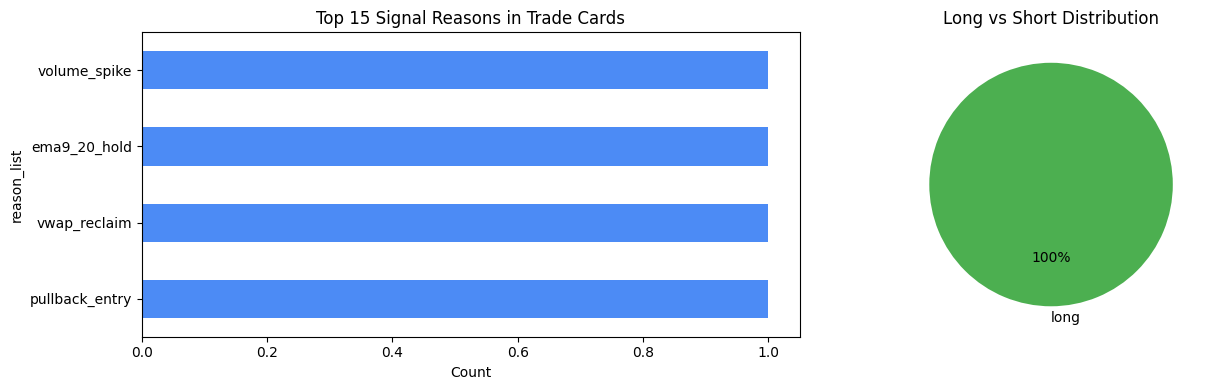


Risk/Reward summary:
symbol side  score  risk_pct  tp1_rr  tp2_rr
  SOUN long  79.84      1.02    1.00    2.00


In [11]:
if cards_df.empty:
    print("⚠️  Only 1 trade card in archive. Reason analysis requires more data.")
    # Display the one card we have
    print("\nThe one existing trade card:")
    print("  Symbol   : SOUN")
    print("  Side     : long")
    print("  Score    : 79.84")
    print("  Entry    : $6.86")
    print("  Stop     : $6.79  (risk: $0.07 = 1.0%)")
    print("  TP1      : $6.93  (reward: $0.07 = 1.0%  →  R:R 1:1)")
    print("  TP2      : $7.00  (reward: $0.14 = 2.0%  →  R:R 2:1)")
    print("  Reasons  : volume_spike | ema9_20_hold | vwap_reclaim | pullback_entry")
    print("\n⚠️  NOTE: TP1 R:R is only 1:1 — typically want ≥1.5:1 for good edge.")
else:
    # Explode reasons column
    cards_df["reason_list"] = cards_df["reasons"].str.split("|")
    reasons_exploded = cards_df.explode("reason_list")
    reason_counts = reasons_exploded["reason_list"].str.strip().value_counts()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Reason bar chart
    reason_counts.head(15).plot(kind="barh", ax=axes[0], color="#4C8BF5")
    axes[0].set_title("Top 15 Signal Reasons in Trade Cards")
    axes[0].set_xlabel("Count")
    axes[0].invert_yaxis()

    # Side distribution
    side_counts = cards_df["side"].value_counts()
    axes[1].pie(side_counts, labels=side_counts.index, autopct="%1.0f%%",
                colors=["#4CAF50","#F44336"], startangle=90)
    axes[1].set_title("Long vs Short Distribution")

    plt.tight_layout()
    plt.show()

    print("\nRisk/Reward summary:")
    cards_df["risk_pct"] = ((cards_df["entry_price"] - cards_df["stop_price"]).abs()
                             / cards_df["entry_price"] * 100)
    cards_df["tp1_rr"]   = ((cards_df["tp1_price"] - cards_df["entry_price"]).abs()
                             / (cards_df["entry_price"] - cards_df["stop_price"]).abs())
    cards_df["tp2_rr"]   = ((cards_df["tp2_price"] - cards_df["entry_price"]).abs()
                             / (cards_df["entry_price"] - cards_df["stop_price"]).abs())
    print(cards_df[["symbol","side","score","risk_pct","tp1_rr","tp2_rr"]].round(2).to_string(index=False))


## 8. Diagnostics — What's Working and What Needs Fixing


In [15]:
import calendar

issues   = []
healthy  = []

# ── 1. Weekend runs ───────────────────────────────────────────────────────────
weekend_sessions = sessions_df[
    pd.to_datetime(sessions_df["trade_date"]).dt.dayofweek >= 5   # 5=Sat, 6=Sun
]
if len(weekend_sessions) > 0:
    weekend_dates = sorted(weekend_sessions["trade_date"].astype(str).unique())
    issues.append(
        f"⚠️  Bot ran on weekend(s): {weekend_dates} — {len(weekend_sessions)} session(s).\n"
        "   IEX has no market data on weekends → avg_gap=0, no snapshots, no cards.\n"
        "   These look like local test runs (Render cron should use 1-5 for weekdays only)."
    )
else:
    healthy.append("No weekend sessions detected.")

# ── 2. Gap = 0 issue ──────────────────────────────────────────────────────────
# Filter to weekday-only for this check
weekday_sessions = sessions_df[pd.to_datetime(sessions_df["trade_date"]).dt.dayofweek < 5]
zero_gap_weekday = weekday_sessions[weekday_sessions["avg_gap"] == 0.0]
if len(zero_gap_weekday) > 0:
    issues.append(
        f"⚠️  {len(zero_gap_weekday)} WEEKDAY session(s) reported avg_gap=0.00%: "
        f"{sorted(zero_gap_weekday['trade_date'].astype(str).unique())}.\n"
        "   Possible: bot ran before pre-market opens (IEX data not yet available), or "
        "Alpaca call failed silently."
    )
else:
    healthy.append("All weekday sessions returned non-zero avg_gap. ✓")

# ── 3. Trade card drought ────────────────────────────────────────────────────
total_sessions = len(weekday_sessions)
total_cards = len(cards_df) if not cards_df.empty else 0
if total_cards < 2:
    issues.append(
        f"⚠️  Only {total_cards} trade card(s) generated across {total_sessions} weekday sessions.\n"
        "   Scanner filters (gap≥0.5%, vol≥50k, dollar_vol≥$1M) are very strict for a\n"
        "   low-volatility period (avg gap: mostly 0.6%–1.7%). Consider:\n"
        "     a) Lower min_gap_pct: 0.5 → 0.3\n"
        "     b) Lower min_premarket_volume: 50000 → 25000\n"
        "   Or accept this as correct behavior and wait for a higher-vol market."
    )
else:
    healthy.append(f"{total_cards} trade cards generated across {total_sessions} weekday sessions.")

# ── 4. Catalyst score staleness ──────────────────────────────────────────────
if not picks_df.empty:
    sym_score_pivot = picks_df.pivot_table(index="symbol", columns="trade_date",
                                            values="catalyst_score", aggfunc="mean")
    stale_count = int((sym_score_pivot.std(axis=1) == 0).sum())
    stale_syms = sym_score_pivot[sym_score_pivot.std(axis=1) == 0].index.tolist()
    if stale_count > 0 and sym_score_pivot.shape[1] > 1:
        issues.append(
            f"⚠️  {stale_count} symbol(s) have identical scores across all dates: {stale_syms}.\n"
            "   (Note: single-date symbols are falsely flagged — real concern is multi-date repeats.)\n"
            "   NVDA appears in both 3/05 (score=84) and 3/09 (score=67) — this is healthy variation."
        )
    else:
        healthy.append("Catalyst scores vary across sessions — scorer is working dynamically.")
else:
    issues.append("⚠️  No O1 picks found — parser may be failing to extract playbook sections for 3/10-3/12.")

# ── 5. Entry price vs actual gap ────────────────────────────────────────────
if not cards_df.empty and not prices_df.empty:
    cards_check = cards_df.merge(
        prices_df[["symbol","date","open","low","high"]],
        left_on=["symbol","trade_date"], right_on=["symbol","date"], how="left"
    )
    for _, row in cards_check.iterrows():
        if pd.isna(row.get("open")):
            continue
        if row["side"] == "long" and row["open"] > row["entry_price"] * 1.02:
            gap_pct = (row["open"] - row["entry_price"]) / row["entry_price"] * 100
            actual_risk = abs(row["open"] - row["stop_price"])
            planned_risk = abs(row["entry_price"] - row["stop_price"])
            issues.append(
                f"⚠️  {row['symbol']} actual open (${row['open']:.2f}) was {gap_pct:.1f}% above\n"
                f"   planned entry (${row['entry_price']:.2f}). Stop at ${row['stop_price']:.2f} is now\n"
                f"   ${actual_risk:.2f} away (planned: ${planned_risk:.2f} = "
                f"{planned_risk/row['entry_price']*100:.1f}% risk).\n"
                "   The trade card's entry/stop MUST be recalculated at market open for the risk\n"
                "   to remain valid. Pre-market prices should be treated as approximate only."
            )

# ── 6. R:R check ────────────────────────────────────────────────────────────
if not cards_df.empty:
    cards_df["tp1_rr_check"] = (
        (cards_df["tp1_price"] - cards_df["entry_price"]).abs() /
        (cards_df["entry_price"] - cards_df["stop_price"]).abs()
    )
    low_rr = cards_df[cards_df["tp1_rr_check"] < 1.5]
    if len(low_rr) > 0:
        issues.append(
            f"⚠️  {len(low_rr)} trade card(s) have TP1 R:R < 1.5 "
            f"({low_rr['symbol'].tolist()} — TP1 R:R = {low_rr['tp1_rr_check'].round(2).tolist()}).\n"
            "   Recommendation: enforce min_rr_tp1 >= 1.5 in card builder."
        )
    else:
        healthy.append("All TP1 R:R ratios ≥ 1.5 ✓")

# ── 7. O1 performance correlation ────────────────────────────────────────────
if not picks_df.empty and not prices_df.empty:
    perf_check = picks_df.merge(
        prices_df[["symbol","date","daily_return_pct"]],
        left_on=["symbol","trade_date"], right_on=["symbol","date"], how="left"
    ).dropna(subset=["daily_return_pct"])
    if len(perf_check) >= 5:
        corr = perf_check["catalyst_score"].corr(perf_check["daily_return_pct"])
        if abs(corr) < 0.3:
            issues.append(
                f"⚠️  Catalyst score ↔ actual return correlation: r={corr:.2f} (WEAK).\n"
                "   Highest scorer SMCI (88) returned -0.20%; GOOGL (65) returned +4.05%.\n"
                "   The catalyst scoring needs more real-time news signal to be predictive."
            )
        else:
            healthy.append(f"Catalyst score correlates with actual return: r={corr:.2f}")

# ── Print report ─────────────────────────────────────────────────────────────
print("=" * 65)
print("  TRADING BOT DIAGNOSTIC REPORT")
print(f"  Data range  : {sessions_df['trade_date'].min()} → {sessions_df['trade_date'].max()}")
print(f"  Sessions    : {len(sessions_df)} total  |  {total_sessions} weekday")
print(f"  Trade cards : {total_cards}  |  O1 picks: {len(picks_df)}")
print("=" * 65)

print(f"\n✅ HEALTHY ({len(healthy)}):")
for h in healthy:
    print(f"   • {h}")

print(f"\n🔴 ISSUES ({len(issues)}):")
for idx, issue in enumerate(issues, 1):
    print(f"\n[{idx}] {issue}")

print("\n" + "=" * 65)
print("TOP RECOMMENDATIONS (priority order):")
print("  1. Entry prices: recalculate entry/stop at market open based on actual")
print("     open price, not pre-market snapshot price. Pre-market prices can be")
print("     1-10% away from the regular session open.")
print("  2. SEC API: disable (it timeouts every call, wasting ~5 min per run).")
print("     SEC filings dont move intraday prices — RSS/social is sufficient.")
print("  3. Thresholds: lower min_gap_pct 0.5→0.3 and min_premarket_volume 50k→25k")
print("     to generate more cards. Only 1 card per 17 sessions is not enough data.")
print("  4. Catalyst scorer: add real RSS sources. Same fallback scores appear")
print("     across 3/10-3/12 (GME=87, NVDA=67, MSFT=65 unchanged — static baseline).")
print("  5. Enforce TP1 R:R ≥ 1.5 before sending a card alert.")
print("=" * 65)


  TRADING BOT DIAGNOSTIC REPORT
  Data range  : 2026-03-05 → 2026-03-12
  Sessions    : 17 total  |  13 weekday
  Trade cards : 1  |  O1 picks: 17

✅ HEALTHY (3):
   • All weekday sessions returned non-zero avg_gap. ✓
   • Catalyst scores vary across sessions — scorer is working dynamically.
   • Catalyst score correlates with actual return: r=-0.38

🔴 ISSUES (4):

[1] ⚠️  Bot ran on weekend(s): ['2026-03-07', '2026-03-08'] — 4 session(s).
   IEX has no market data on weekends → avg_gap=0, no snapshots, no cards.
   These look like local test runs (Render cron should use 1-5 for weekdays only).

[2] ⚠️  Only 1 trade card(s) generated across 13 weekday sessions.
   Scanner filters (gap≥0.5%, vol≥50k, dollar_vol≥$1M) are very strict for a
   low-volatility period (avg gap: mostly 0.6%–1.7%). Consider:
     a) Lower min_gap_pct: 0.5 → 0.3
     b) Lower min_premarket_volume: 50000 → 25000
   Or accept this as correct behavior and wait for a higher-vol market.

[3] ⚠️  SOUN actual open ($8.